In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
import torchvision.transforms as transforms
import torchvision.models as models
from torchvision.datasets import ImageFolder

# Check GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [4]:
# ImageNet mean and std since we use pretrained weights
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

In [5]:
DATA_DIR = "dataset"  # Folder with 3 subfolders (one per disease class)

# Load full dataset first (just to get labels and indices)
full_dataset = ImageFolder(root=DATA_DIR)

print(f"Classes: {full_dataset.classes}")
print(f"Total images: {len(full_dataset)}")

# Get all indices and labels
all_indices = list(range(len(full_dataset)))
all_labels  = [full_dataset.targets[i] for i in all_indices]

# First split: 80% train+val, 20% test
train_val_idx, test_idx = train_test_split(
    all_indices,
    test_size=0.2,
    stratify=all_labels,   # ensures equal class distribution
    random_state=42
)

# Second split: from 80%, take 75% train and 25% val → final: 60/20/20
train_val_labels = [all_labels[i] for i in train_val_idx]

train_idx, val_idx = train_test_split(
    train_val_idx,
    test_size=0.25,
    stratify=train_val_labels,
    random_state=42
)

print(f"Train: {len(train_idx)} | Val: {len(val_idx)} | Test: {len(test_idx)}")

# Now create three separate dataset objects with different transforms
train_dataset = ImageFolder(root=DATA_DIR, transform=train_transforms)
val_dataset   = ImageFolder(root=DATA_DIR, transform=val_test_transforms)
test_dataset  = ImageFolder(root=DATA_DIR, transform=val_test_transforms)

# Apply the index splits
train_data = Subset(train_dataset, train_idx)
val_data   = Subset(val_dataset,   val_idx)
test_data  = Subset(test_dataset,  test_idx)

# DataLoaders
BATCH_SIZE = 16

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_data,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_data,  batch_size=BATCH_SIZE, shuffle=False)

Classes: ['algal leaf', 'brown blight', 'white spot']
Total images: 368
Train: 220 | Val: 74 | Test: 74


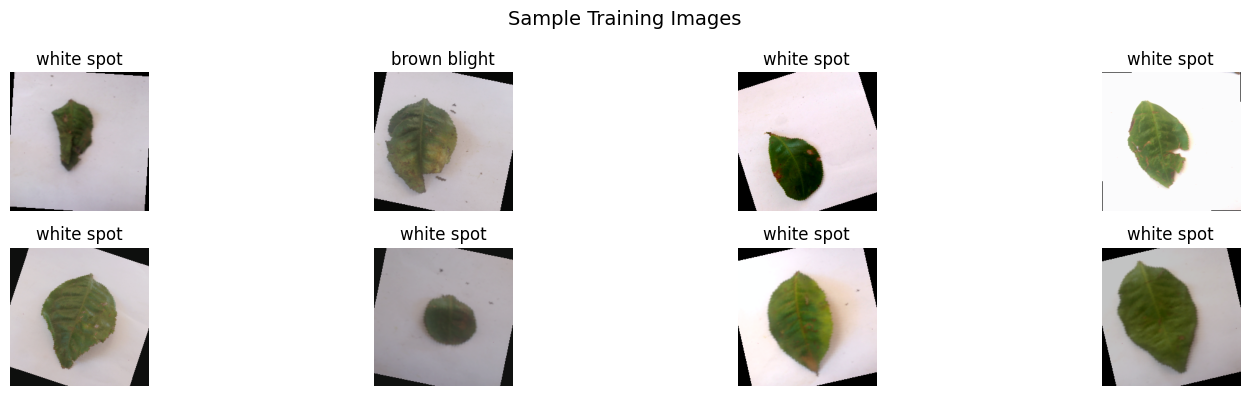

In [6]:
def imshow(img, title=None):
    img = img.numpy().transpose((1, 2, 0))
    img = img * IMAGENET_STD + IMAGENET_MEAN   # unnormalize
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    if title:
        plt.title(title)
    plt.axis('off')

class_names = full_dataset.classes

# Show one batch
images, labels = next(iter(train_loader))
plt.figure(figsize=(16, 4))
for i in range(8):
    plt.subplot(2, 4, i+1)
    imshow(images[i], title=class_names[labels[i]])
plt.suptitle("Sample Training Images", fontsize=14)
plt.tight_layout()
plt.savefig("sample_images.png", dpi=150)
plt.show()

In [8]:
def build_vgg16(num_classes=3, freeze_features=True):
    model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)

    # Freeze feature extractor
    if freeze_features:
        for param in model.features.parameters():
            param.requires_grad = False

    # Replace classifier — fully customizable
    model.classifier = nn.Sequential(
        nn.Linear(25088, 1024),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(1024, 256),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(256, num_classes)
    )

    return model.to(device)

vgg_model = build_vgg16(num_classes=3, freeze_features=True)
print(vgg_model)

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to C:\Users\ASUS/.cache\torch\hub\checkpoints\vgg16-397923af.pth


100.0%


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [9]:
def build_resnet50(num_classes=3, freeze_backbone=True):
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

    # Freeze backbone layers
    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False

    # Replace final FC layer — fully customizable
    in_features = model.fc.in_features  # 2048
    model.fc = nn.Sequential(
        nn.Linear(in_features, 512),
        nn.ReLU(),
        nn.Dropout(0.4),
        nn.Linear(512, 128),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(128, num_classes)
    )

    return model.to(device)

resnet_model = build_resnet50(num_classes=3, freeze_backbone=True)
print(resnet_model)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to C:\Users\ASUS/.cache\torch\hub\checkpoints\resnet50-0676ba61.pth


100.0%


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [12]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc  = correct / total
    return epoch_loss, epoch_acc


def evaluate(model, loader, criterion):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc  = correct / total
    return epoch_loss, epoch_acc

In [14]:
def train_model(model, model_name, train_loader, val_loader,
                num_epochs=25, lr=0.001, patience=5):

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), lr=lr
    )
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=3,
    )

    history = {"train_loss": [], "val_loss": [],
               "train_acc":  [], "val_acc":  []}

    best_val_acc  = 0.0
    patience_counter = 0
    best_model_path = f"best_{model_name}.pth"

    for epoch in range(num_epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        val_loss,   val_acc   = evaluate(model, val_loader, criterion)

        scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"[{model_name}] Epoch {epoch+1}/{num_epochs} | "
              f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), best_model_path)
            print(f"  --> Best model saved (val_acc: {best_val_acc:.4f})")
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping triggered at epoch {epoch+1}")
                break

    # Load best weights back
    model.load_state_dict(torch.load(best_model_path))
    print(f"\nTraining complete. Best Val Acc: {best_val_acc:.4f}")
    return model, history


# Train VGG16
print("=" * 50)
print("Training VGG16...")
vgg_model, vgg_history = train_model(
    vgg_model, "VGG16", train_loader, val_loader, num_epochs=25, lr=0.001
)

# Train ResNet50
print("=" * 50)
print("Training ResNet50...")
resnet_model, resnet_history = train_model(
    resnet_model, "ResNet50", train_loader, val_loader, num_epochs=25, lr=0.001
)

Training VGG16...
[VGG16] Epoch 1/25 | Train Loss: 2.4137 Acc: 0.3273 | Val Loss: 1.1612 Acc: 0.3108
  --> Best model saved (val_acc: 0.3108)
[VGG16] Epoch 2/25 | Train Loss: 1.5287 Acc: 0.4045 | Val Loss: 1.2921 Acc: 0.2973
[VGG16] Epoch 3/25 | Train Loss: 1.1636 Acc: 0.4636 | Val Loss: 0.9140 Acc: 0.5676
  --> Best model saved (val_acc: 0.5676)
[VGG16] Epoch 4/25 | Train Loss: 1.0486 Acc: 0.5136 | Val Loss: 0.8950 Acc: 0.5676
[VGG16] Epoch 5/25 | Train Loss: 0.9130 Acc: 0.6227 | Val Loss: 0.8463 Acc: 0.7027
  --> Best model saved (val_acc: 0.7027)
[VGG16] Epoch 6/25 | Train Loss: 0.9139 Acc: 0.6091 | Val Loss: 0.8332 Acc: 0.6892
[VGG16] Epoch 7/25 | Train Loss: 0.9123 Acc: 0.5727 | Val Loss: 0.8310 Acc: 0.7162
  --> Best model saved (val_acc: 0.7162)
[VGG16] Epoch 8/25 | Train Loss: 0.7898 Acc: 0.6636 | Val Loss: 0.7421 Acc: 0.7297
  --> Best model saved (val_acc: 0.7297)
[VGG16] Epoch 9/25 | Train Loss: 0.7796 Acc: 0.7136 | Val Loss: 0.8308 Acc: 0.6757
[VGG16] Epoch 10/25 | Train Lo

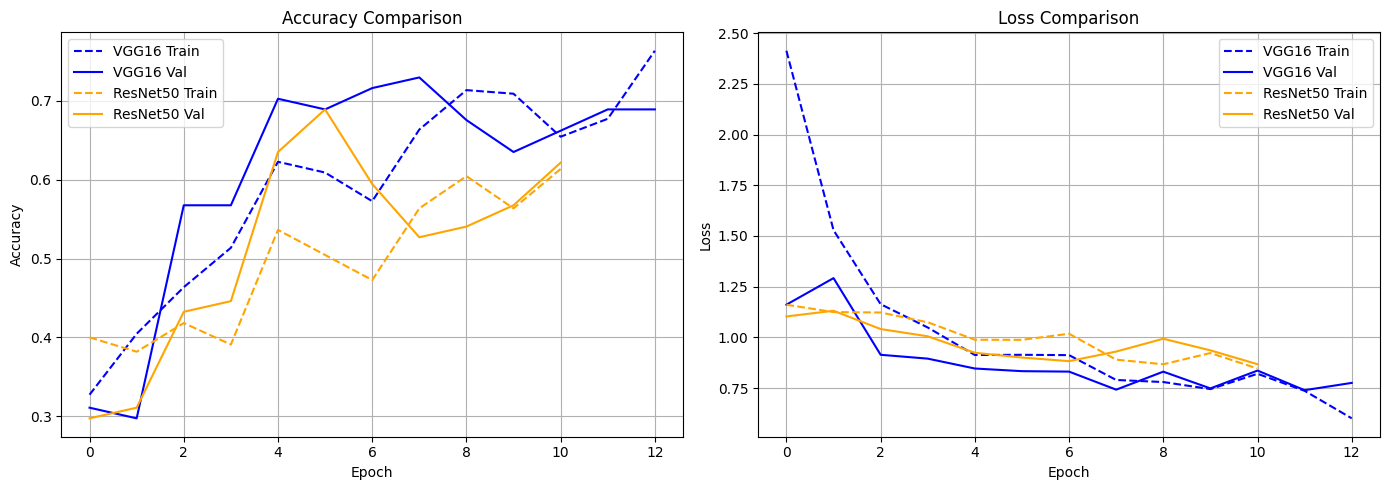

In [15]:
def plot_history(vgg_hist, resnet_hist):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # --- Accuracy ---
    axes[0].plot(vgg_hist["train_acc"],    label="VGG16 Train",    color="blue",   linestyle="--")
    axes[0].plot(vgg_hist["val_acc"],      label="VGG16 Val",      color="blue")
    axes[0].plot(resnet_hist["train_acc"], label="ResNet50 Train", color="orange", linestyle="--")
    axes[0].plot(resnet_hist["val_acc"],   label="ResNet50 Val",   color="orange")
    axes[0].set_title("Accuracy Comparison")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend()
    axes[0].grid(True)

    # --- Loss ---
    axes[1].plot(vgg_hist["train_loss"],    label="VGG16 Train",    color="blue",   linestyle="--")
    axes[1].plot(vgg_hist["val_loss"],      label="VGG16 Val",      color="blue")
    axes[1].plot(resnet_hist["train_loss"], label="ResNet50 Train", color="orange", linestyle="--")
    axes[1].plot(resnet_hist["val_loss"],   label="ResNet50 Val",   color="orange")
    axes[1].set_title("Loss Comparison")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.savefig("accuracy_loss_comparison.png", dpi=150)
    plt.show()

plot_history(vgg_history, resnet_history)


VGG16 Classification Report:
              precision    recall  f1-score   support

  algal leaf       0.89      0.74      0.81        23
brown blight       0.80      0.70      0.74        23
  white spot       0.74      0.93      0.83        28

    accuracy                           0.80        74
   macro avg       0.81      0.79      0.79        74
weighted avg       0.81      0.80      0.80        74



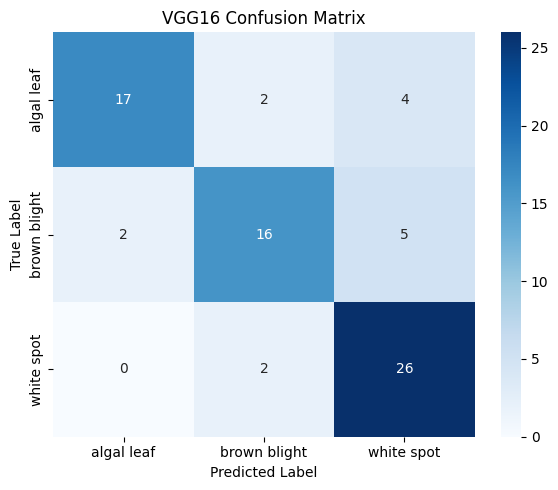


ResNet50 Classification Report:
              precision    recall  f1-score   support

  algal leaf       0.88      0.61      0.72        23
brown blight       0.67      0.52      0.59        23
  white spot       0.68      0.96      0.79        28

    accuracy                           0.72        74
   macro avg       0.74      0.70      0.70        74
weighted avg       0.73      0.72      0.71        74



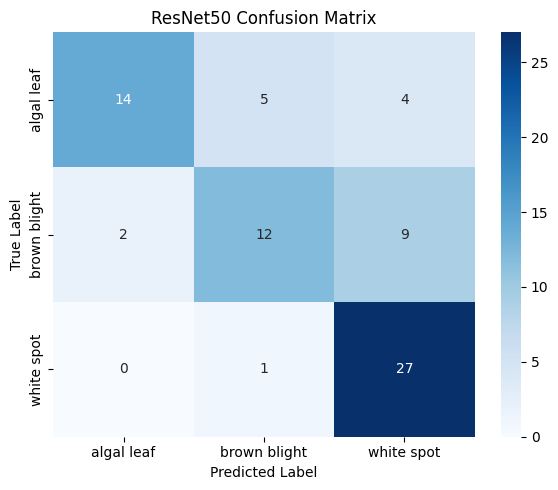

In [16]:
def get_predictions(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())
    return np.array(all_labels), np.array(all_preds)


def plot_confusion_matrix(true, pred, class_names, title, filename):
    cm = confusion_matrix(true, pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(title)
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.tight_layout()
    plt.savefig(filename, dpi=150)
    plt.show()


# VGG16 Test Evaluation
vgg_true, vgg_pred = get_predictions(vgg_model, test_loader)
print("\nVGG16 Classification Report:")
print(classification_report(vgg_true, vgg_pred, target_names=class_names))
plot_confusion_matrix(vgg_true, vgg_pred, class_names,
                      "VGG16 Confusion Matrix", "vgg_cm.png")

# ResNet50 Test Evaluation
res_true, res_pred = get_predictions(resnet_model, test_loader)
print("\nResNet50 Classification Report:")
print(classification_report(res_true, res_pred, target_names=class_names))
plot_confusion_matrix(res_true, res_pred, class_names,
                      "ResNet50 Confusion Matrix", "resnet_cm.png")